![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [ ]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [ ]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

In [ ]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

In [ ]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


In [ ]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [ ]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

In [ ]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

In [ ]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

In [ ]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

In [ ]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


## 3. Complete Layout

In [ ]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

In [ ]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [ ]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

In [ ]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


In [ ]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercise. 


- Now, add another MMI Tree, but in this case, with three levels. 
- You **must** define a PCell to define this structure
- Add two instances of your new parametric cell varying any parameter such as the pad on x or y, etc
- Connect the MMIs with output waveguides at the right side of the die. 

## 5. MTP lab 


## 5.0 Variables

In [1]:
import gdsfactory as gf 

import sys
print(sys.executable)

print(sys.path)
sys.path.insert(0, "/Users/pascual/Desktop/pic-upv-lab4/src")

from upvfab.sin300.cband import PDK, cells
from upvfab.sin300.cband.tech import LOENCAPS, LAYER


/Users/pascual/Desktop/pic-upv-lab4/.venv/bin/python
['/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python312.zip', '/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12', '/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/lib-dynload', '', '/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages']


In [2]:
# Variables

l_coupon = 2050
w_coupon = 180

l_ridge = l_coupon - 20.0
w_ridge = w_coupon - 20.0

w_trench = 25
sep_trench = 10

l_milano = 100
w_milano_W = 30
w_milano_w = 10

l_milano_t = 60
w_milano_Wt = 30
w_milano_wt = 10

milan_sep = 150

l_marker = 50
w_marker = 20
marker_sep =20

w_feet = 30
w_break = 4

L_vernier=3
W_vernier=20

## 5.1 Marker Component

### Example 

/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'diagcross' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'left-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'right-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'zigzag' does not correspond to any KLayout built-in or custom pattern! Using 'I3

2026-05-04 17:55:25.437 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/3558597104.oas'
2026-05-04 17:55:25.682 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/3558597104.oas'


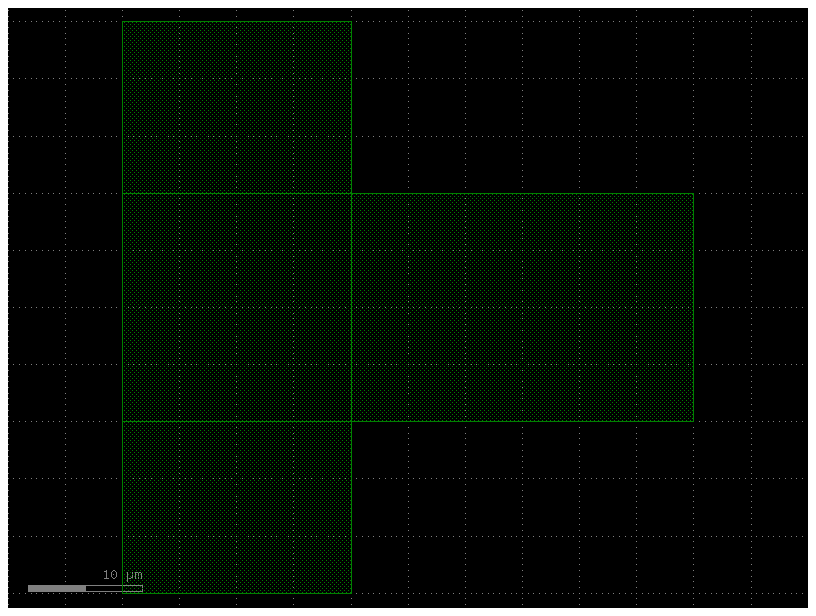

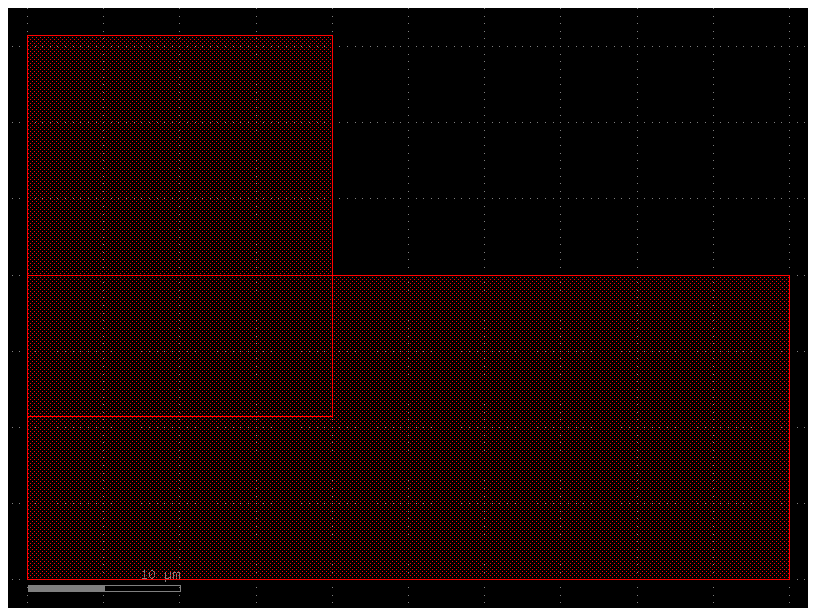

In [3]:
markerC = gf.Component()
rect1 = gf.components.straight(
    length = l_marker,
    width = w_marker,
    cross_section="cs_oencaps"
)
rect2 = gf.components.straight(
    length = w_marker,
    width = l_marker/2,
    cross_section="cs_oencaps"
)
R1 = markerC.add_ref(rect1)
R2 = markerC.add_ref(rect2)
R2.move((0,w_marker*0.66))

markerT = gf.Component()
rect1T = gf.components.straight(
    length = l_marker,
    width = w_marker,
    cross_section="cs_tmilano"
)
rect2T = gf.components.straight(
    length = w_marker,
    width = l_marker,
    cross_section="cs_tmilano"
)

R1T = markerT.add_ref(rect1T)
R2T = markerT.add_ref(rect2T)
#R2T.move((l_marker/2-w_marker/2,0))

markerT.plot()
markerC.plot()

markerT.show()
markerC.show()

### MTP design #1 – Alignment marks 

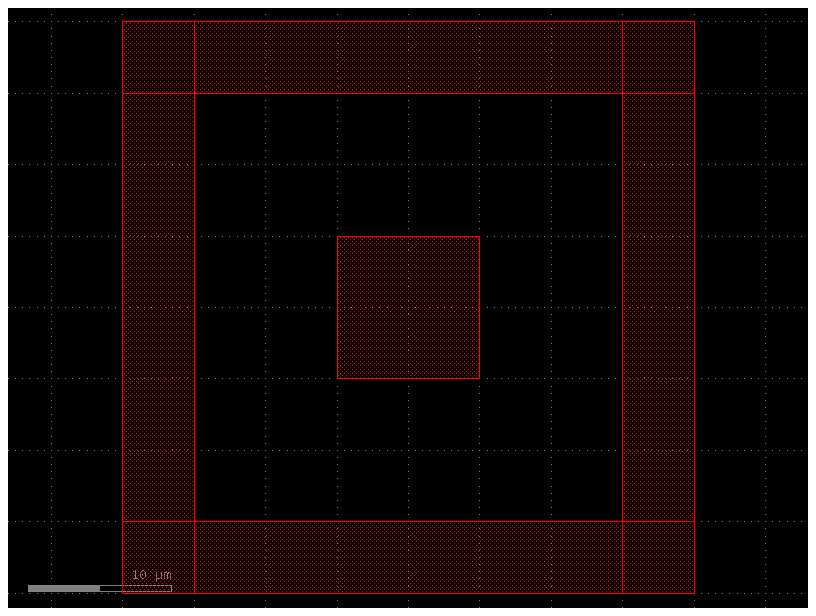

In [4]:
# STUDENT CODE GOES HERE

w_block = 5.0

# Create empty component
markerB = gf.Component()

# Create shapes
square = gf.components.straight(
    length = 2*w_block,
    width = 2*w_block,
    cross_section="cs_oencaps"
)

line = gf.components.straight(
    length = 8*w_block,
    width = 1*w_block,
    cross_section="cs_oencaps"
)

# Add shapes to the component
SQ = markerB.add_ref(square)
LN1 = markerB.add_ref(line)
LN2 = markerB.add_ref(line)
LN3 = markerB.add_ref(line)
LN4 = markerB.add_ref(line)

# Move the shapes relative to each other
# Let's center the square
SQ.move((-w_block,0))
LN1.move((-4*w_block,+3.5*w_block))
LN2.move((-4*w_block,-3.5*w_block))

LN3.rotate(90)
LN3.move((-3.5*w_block,-4*w_block))
LN4.rotate(90)
LN4.move((+3.5*w_block,-4*w_block))

# Plot the component
markerB.plot()

## 5.2. Coupon component

### Example - coupon body

2026-05-04 17:55:26.048 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/1745490960.oas'
2026-05-04 17:55:26.295 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/1745490960.oas'


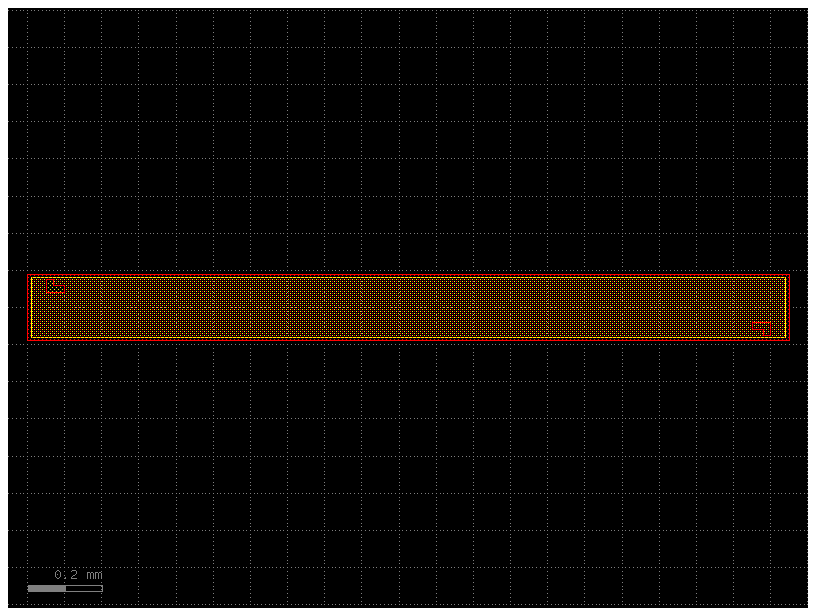

In [5]:
# Rectange in the encapsulation layer
coupon = gf.components.straight(
    length = l_coupon,
    width = w_coupon,
    cross_section="cs_oencaps",
)

# Rectangle in the coupon layer
ridge = gf.components.straight(
    length = l_ridge,
    width = w_ridge,
    cross_section="cs_ocoupon",
)

# Auxiliar component - purpose have coupon with the markers etched through it
cm = gf.Component("Aux") # empty component
coup=cm.add_ref(coupon) # shape coupon
ml=cm.add_ref(markerC).move((50,50)) # marker left
mr=cm.add_ref(markerC).move((-2000,50)).rotate(180) # marker at right
# rg = cm.add_ref(ridge).move((20,0))
cm.show() # shows the coupon overlapping with the markers


# But we want the markers etched through the coupon
#couponwithmarker = gf.Component("CouponwithMarkers")
couponwithmarker = gf.Component()
c = couponwithmarker.add_ref(ridge).move((10,0))

#b = couponwithmarker.add_ref(gf.boolean(A=cm, B=[ml,mr], operation="A-B", layer=LOENCAPS))
b = couponwithmarker.add_ref(gf.boolean(A=cm, B=ml, operation="A-B", layer=LOENCAPS))
c = couponwithmarker.add_ref(gf.boolean(A=b, B=mr, operation="A-B", layer=LOENCAPS))

couponwithmarker.plot()
couponwithmarker.show()

In [6]:
#TRENCHES RECTANGULARES
trench_h = gf.components.straight(
    length = 2*(w_trench+sep_trench) + l_coupon,
    width = w_trench,
    cross_section="cs_otrench"
)
trench_v = gf.components.straight(
    length = w_trench,
    width = 2*(w_trench+sep_trench) + w_coupon,
    cross_section="cs_otrench"
)

### Example - trench & encapsulation feet

DPort(self.name='o1', self.width=30.0, trans=r180 *1 0,0, layer=OTRENCH (121/0), port_type=optical)

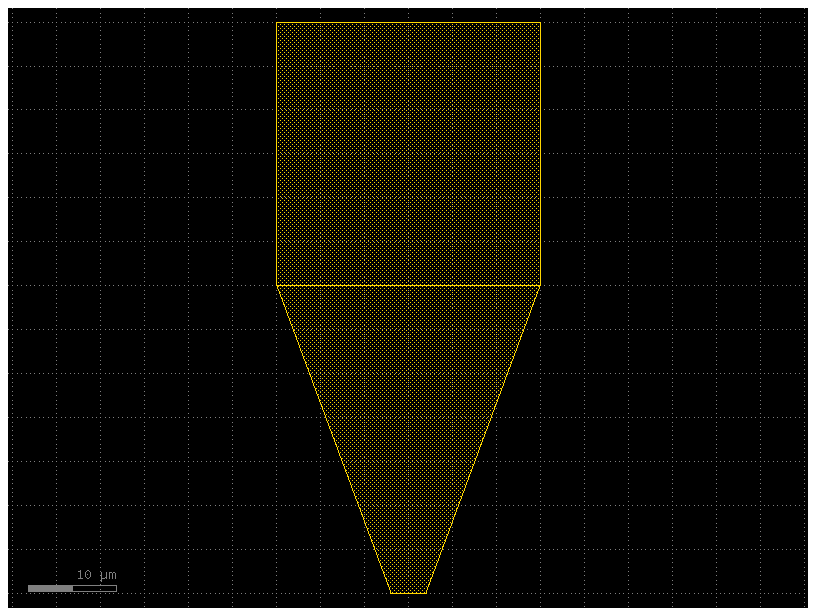

In [11]:
# Trench shape for encapsulation feet

trench_feet = gf.Component()
trench_feet_square = gf.components.straight(
    length = w_feet,
    width = w_feet,
    cross_section="cs_otrench"
)
trench_feet_taper_1 = gf.components.taper(
    length = w_trench + sep_trench,
    width1 = w_break,
    width2 = w_feet,
    cross_section="cs_otrench"
)
tfs = trench_feet.add_ref(trench_feet_square).rotate(90)
tft1 = trench_feet.add_ref(trench_feet_taper_1).rotate(90)


#tfs.connect("o1", destination=tft1.ports["o2"])
tfs.connect(port="o1", other=tft1.ports["o2"])

trench_feet.plot()
# Add ports
trench_feet.add_port(
    name="o1",
    center=(0,0),
    width=w_feet,
    orientation=180,
    cross_section="cs_otrench",
    port_type="optical",
    layer=LAYER.OTRENCH,
)

/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'diagcross' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'left-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'right-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'zigzag' does not correspond to any KLayout built-in or custom pattern! Using 'I3

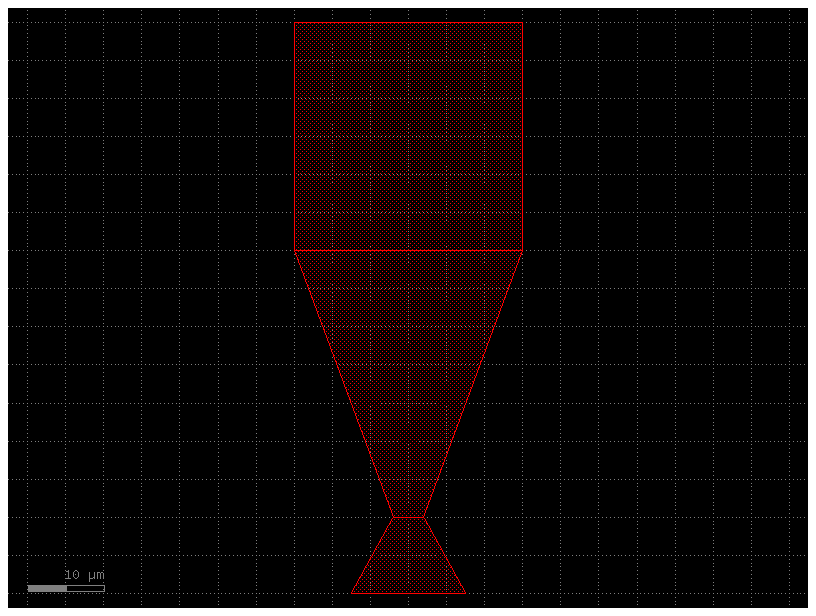

In [12]:
# Encapsulation feet

phr_feet = gf.Component()
phr_feet_square = gf.components.straight(
    length = w_feet,
    width = w_feet,
    cross_section="cs_oencaps"
)
phr_feet_taper_1 = gf.components.taper(
    length = w_trench + sep_trench,
    width1 = w_break,
    width2 = w_feet,
    cross_section="cs_oencaps"
)
phr_feet_taper_2 = gf.components.taper(
    length = sep_trench,
    width1 = w_feet/2 ,
    width2 = w_break,
    cross_section="cs_oencaps"
)
pfs = phr_feet.add_ref(phr_feet_square).rotate(90)
pft1 = phr_feet.add_ref(phr_feet_taper_1).rotate(90)
pft2 = phr_feet.add_ref(phr_feet_taper_2).rotate(90)

pft1.connect("o1", other=pft2.ports["o2"])
pfs.connect("o1", other=pft1.ports["o2"])

phr_feet.plot()

### Example - compose coupon with the different components

2026-05-04 17:58:45.690 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/3852785122.oas'


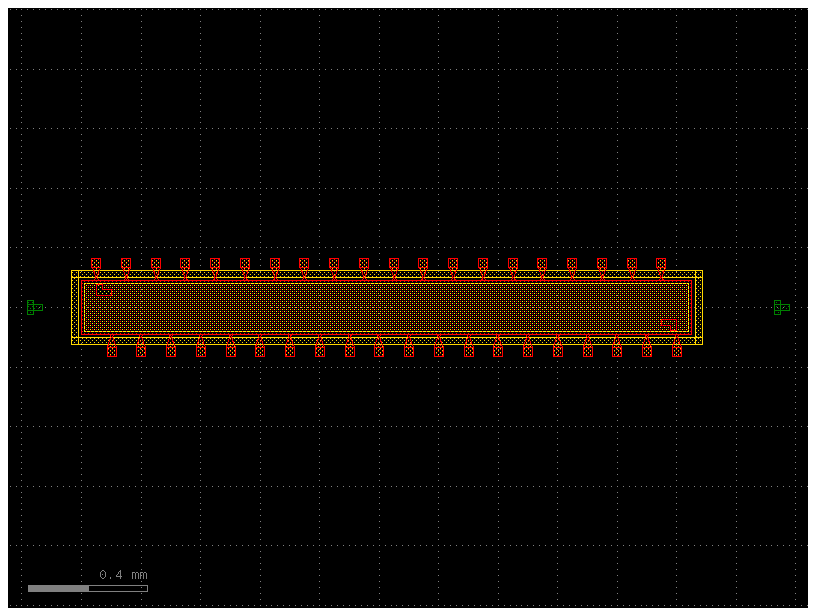

In [13]:
c = gf.Component()

# Coupon component
c.add_ref(couponwithmarker)

# Trenches
th_h1 = c.add_ref(trench_h)
th_h2 = c.add_ref(trench_h)

th_h1.move((-w_trench-sep_trench,+(0.5*(w_coupon+w_trench)+sep_trench)))
th_h2.move((-w_trench-sep_trench,-(0.5*(w_coupon+w_trench)+sep_trench)))

th_v1 = c.add_ref(trench_v)
th_v2 = c.add_ref(trench_v)

th_v1.move((-(w_trench+sep_trench),0))
th_v2.move((l_coupon+(sep_trench),0))

# Array horizontal superior de huecos para anclas
n_anchors = 20
anchors_sep = 100

trench_array_Hup=[]
phr_array_Hup=[]
trench_array_Hdown=[]
phr_array_Hdown=[]

for i in range(n_anchors):
    trench_array_Hup.append(c.add_ref(trench_feet))
    phr_array_Hup.append(c.add_ref(phr_feet))

    trench_array_Hdown.append(c.add_ref(trench_feet))
    phr_array_Hdown.append(c.add_ref(phr_feet))
    if i == 0:
        trench_array_Hup[i].move(((anchors_sep/2,w_coupon/2+sep_trench)))
        phr_array_Hup[i].move(((anchors_sep/2,w_coupon/2)))

        trench_array_Hdown[i].move(((anchors_sep/2-l_coupon,w_coupon/2+sep_trench))).rotate(180)
        phr_array_Hdown[i].move(((anchors_sep/2-l_coupon,w_coupon/2))).rotate(180)
    else:
        trench_array_Hup[i].move(((i*(anchors_sep)+anchors_sep/2,w_coupon/2+sep_trench)))
        phr_array_Hup[i].move(((i*(anchors_sep)+anchors_sep/2,w_coupon/2)))

        trench_array_Hdown[i].move(((i*(anchors_sep)+anchors_sep/2-l_coupon,w_coupon/2+sep_trench))).rotate(180)
        phr_array_Hdown[i].move(((i*(anchors_sep)+anchors_sep/2-l_coupon,w_coupon/2))).rotate(180)


Tmarkerleft=c.add_ref(markerT).move((-(l_milano/2+l_milano_t+marker_sep+l_marker),0))
Tmarkerright=c.add_ref(markerT).move((l_coupon+l_milano/2+milan_sep+l_milano_t+marker_sep,0))

c.show()
c.plot()

### MTP design #2 – Coupon shapes

/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'diagcross' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'left-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'right-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'zigzag' does not correspond to any KLayout built-in or custom pattern! Using 'I3

2026-05-04 18:04:33.705 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/1020976283.oas'


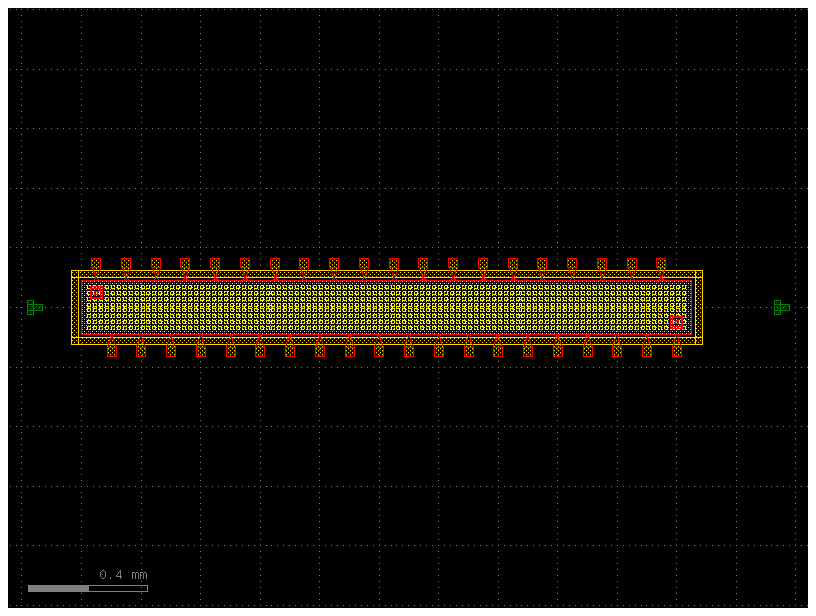

In [26]:
# STUDENT CODE GOES HERE

w_square = 10.0

# Create empty component
BN_coupon = gf.Component()

# Rectangle in the coupon layer
little_square = gf.components.straight(
    length = w_square,
    width = w_square,
    cross_section="cs_ocoupon",
)

our_coupon = gf.components.straight(
    length = l_coupon,
    width = w_coupon,
    cross_section="cs_ocoupon",
)
dXY = 20.0
N_COL = int(l_coupon / dXY) - 1
N_ROW = int(w_coupon / dXY) - 1

little_square_array = gf.components.array(
    component = little_square,
    column_pitch= dXY,
    row_pitch= dXY,
    columns = N_COL,
    rows = N_ROW,
    add_ports = False,
)

# Add shapes to the component
LS = BN_coupon.add_ref(little_square_array)
OC = BN_coupon.add_ref(our_coupon)
LS.move((dXY,-0.5*w_coupon + dXY))

# New component
BN_coupon_b = gf.Component()

# Do boolean
my_boolean = BN_coupon_b.add_ref(gf.boolean(A=OC, B=LS, operation="A-B",layer=LAYER.OCOUPON))


# Rectange in the encapsulation layer
capsule = gf.components.straight(
    length = l_coupon,
    width = w_coupon,
    cross_section="cs_oencaps",
)

CAP = gf.Component()
cap = CAP.add_ref(capsule)
ml=CAP.add_ref(markerB).move((50,50)) # marker left
mr=CAP.add_ref(markerB).move((-2000,50)).rotate(180) # marker at right

# See through alignment marks in the encapsulation layer
my_cap_boolean = BN_coupon_b.add_ref(gf.boolean(A=cap, B=ml, operation="A-B",layer=LAYER.OENCAPS))
my_cap_boolean = BN_coupon_b.add_ref(gf.boolean(A=my_cap_boolean, B=mr, operation="A-B",layer=LAYER.OENCAPS))



# Let's add the silicon trenches
# Trenches
th_h1 = BN_coupon_b.add_ref(trench_h)
th_h2 = BN_coupon_b.add_ref(trench_h)

th_h1.move((-w_trench-sep_trench,+(0.5*(w_coupon+w_trench)+sep_trench)))
th_h2.move((-w_trench-sep_trench,-(0.5*(w_coupon+w_trench)+sep_trench)))

th_v1 = BN_coupon_b.add_ref(trench_v)
th_v2 = BN_coupon_b.add_ref(trench_v)

th_v1.move((-(w_trench+sep_trench),0))
th_v2.move((l_coupon+(sep_trench),0))

# Feet
trench_feet_array = gf.components.array(
    component = trench_feet,
    column_pitch= anchors_sep,
    row_pitch = 0.0,
    columns = n_anchors,
    rows = 1,
    add_ports = False,
)

tfa_top = BN_coupon_b.add_ref(trench_feet_array)
tfa_top.move(((anchors_sep/2,w_coupon/2+sep_trench)))

tfa_bot = BN_coupon_b.add_ref(trench_feet_array)
tfa_bot.move(((anchors_sep/2-l_coupon,w_coupon/2+sep_trench))).rotate(180)

# Photo-resist (encapsulation) feet

# Feet
phr_feet_array = gf.components.array(
    component = phr_feet,
    column_pitch= anchors_sep,
    row_pitch = 0.0,
    columns = n_anchors,
    rows = 1,
    add_ports = False,
)

pfa_top = BN_coupon_b.add_ref(phr_feet_array)
pfa_top.move(((anchors_sep/2,w_coupon/2)))

pfa_bot = BN_coupon_b.add_ref(phr_feet_array)
pfa_bot.move(((anchors_sep/2-l_coupon,w_coupon/2))).rotate(180)

# Target wafer alignment marks
Tmarkerleft=BN_coupon_b.add_ref(markerT).move((-(l_milano/2+l_milano_t+marker_sep+l_marker),0))
Tmarkerright=BN_coupon_b.add_ref(markerT).move((l_coupon+l_milano/2+milan_sep+l_milano_t+marker_sep,0))


# Plot component
BN_coupon_b.plot()
BN_coupon_b.show()

## 5.3. Full coupon layout and array of coupons

### Example - compose die with array of coupons

2026-05-04 18:05:28.408 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/1612192399.oas'


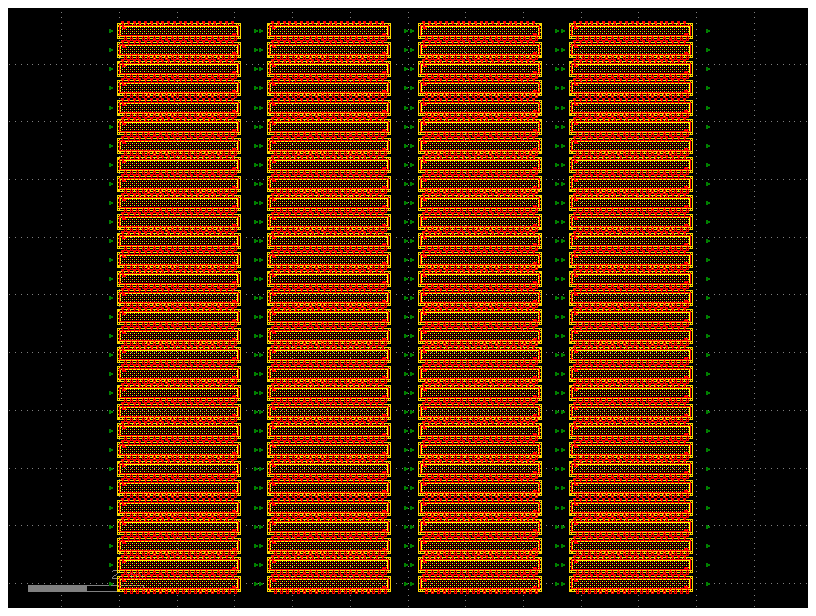

In [27]:
# CREATE RETICLE OF COUPONS
reticulo = gf.Component("DummyCouponsReticle")
for i in range (4):
    for j in range (30):
        x = i* (l_coupon+2*(l_milano/2+milan_sep+l_milano_t+marker_sep))
        y = j* (w_coupon+2*(w_trench + 2*sep_trench + w_feet))
        couponsss=reticulo.add_ref(c).move((x,y))
        
reticulo.show()
reticulo.plot()

### MTP design #3 – Full coupon and die layout

/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'diagcross' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'left-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'right-hatch' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(
/Users/pascual/Desktop/pic-upv-lab4/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1053: UserWarning: Dither pattern 'zigzag' does not correspond to any KLayout built-in or custom pattern! Using 'I3

2026-05-04 18:06:18.982 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Users/pascual/Desktop/pic-upv-lab4/build/oas/1952812793.oas'


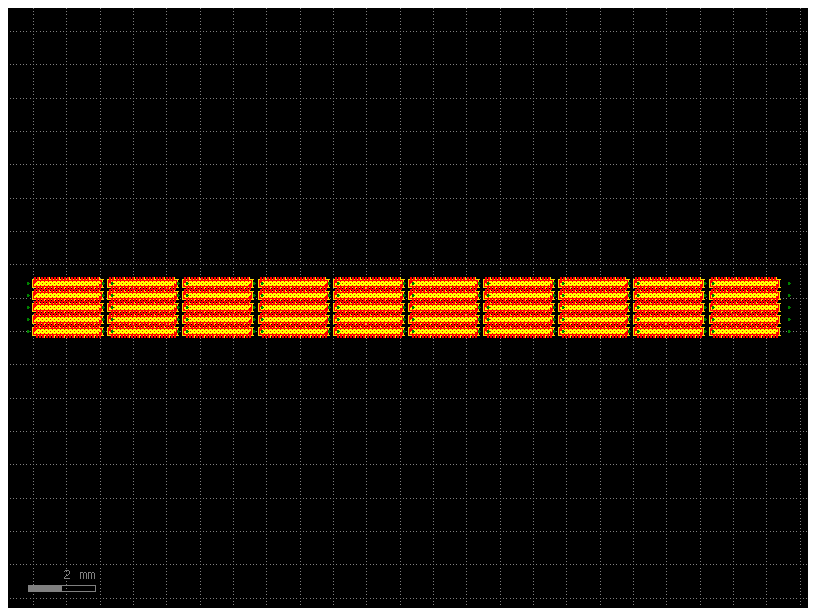

In [29]:
# STUDENT CODE GOES HERE
# Feet
dX_coupon = 1.1*l_coupon
dY_coupon = 2*w_coupon

BN_die = gf.components.array(
    component = BN_coupon_b,
    column_pitch =  dX_coupon, 
    row_pitch = dY_coupon,
    columns = 10,
    rows = 5,
    add_ports = False,
)

BN_die.plot()
BN_die.show()